INFO:ddlpy.ddlpy:Retrieving Waterwebservices catalog, this can take 30 seconds
DEBUG:ddlpy.ddlpy:Requesting at https://ddapi20-waterwebservices.rijkswaterstaat.nl/METADATASERVICES/OphalenCatalogus with request: {"CatalogusFilter": {"WaardeBewerkingsMethoden": true, "Typeringen": true, "Grootheden": true, "Parameters": true, "ProcesTypes": true, "Compartimenten": true, "Hoedanigheden": true, "Organen": true, "BioTaxon": true, "Eenheden": true, "Groeperingen": true}}
100%|██████████| 1/1 [00:00<00:00,  2.22it/s]
DEBUG:ddlpy.ddlpy:0 duplicated values dropped


Data was found in RWS Waterwebservices/DDL


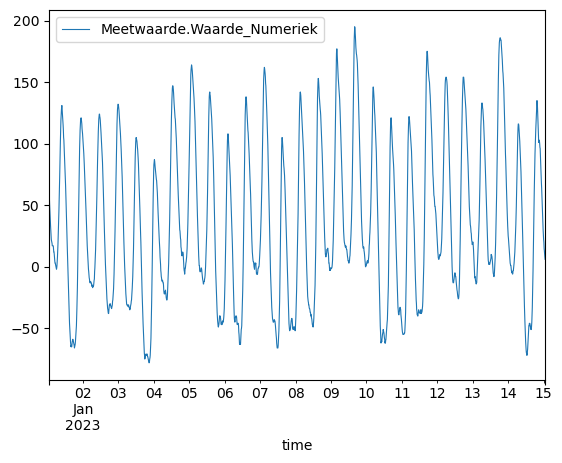

In [1]:
"""
This is a minimal example on how to retrieve data from the DDL with ddlpy.
"""

import ddlpy
import datetime as dt

# enabling debug logging so we can see what happens in the background
import logging
logging.basicConfig()
logging.getLogger("ddlpy").setLevel(logging.DEBUG)

# get the dataframe with locations and their available parameters
locations = ddlpy.locations()

# Filter the locations dataframe with the desired parameters and stations.
bool_stations = locations.index.isin(["ijmuiden.buitenhaven", "dantziggat.zuid", "hoekvanholland", "ameland.nes"])
# meting/astronomisch/verwachting
bool_procestype = locations["ProcesType"].isin(["meting"])
# waterlevel/waterhoogte (WATHTE)
bool_grootheid = locations["Grootheid.Code"].isin(["WATHTE"])
# timeseries ("") versus extremes (GETETM2/GETETMSL2/GETETBRKD2/GETETBRKDMSL2)
bool_groepering = locations["Groepering.Code"].isin([""])
# vertical reference (NAP/MSL)
bool_hoedanigheid = locations["Hoedanigheid.Code"].isin(["NAP"])
selected = locations.loc[
    bool_procestype
    & bool_stations
    & bool_grootheid
    & bool_groepering
    & bool_hoedanigheid
    ]

start_date = dt.datetime(2023, 1, 1)
end_date = dt.datetime(2023, 1, 15)

# provide a single row of the locations dataframe to ddlpy.measurements
measurements = ddlpy.measurements(selected.iloc[0], start_date=start_date, end_date=end_date)

if not measurements.empty:
    print("Data was found in RWS Waterwebservices/DDL")
    measurements.plot(y="Meetwaarde.Waarde_Numeriek", linewidth=0.8)
else:
    print("No Data!")